# AlexNet


## 简介
Alex Krizhevsky 和 Geoffrey Hinton 在 2012 年提出的卷积神经网络架构，在 ImageNet 图像分类挑战赛中取得了显著的成绩，标志着深度学习在计算机视觉领域的突破。

## 网络结构
5 个卷积层和 3 个全连接层组成

![AlexNet](./images/AlexNet.png)

## 与 LeNet 的区别

![LeNet to AlexNet](./images/LeNet_to_AlexNet.svg)

- 更大的卷积核，更多的卷积层、通道数
- 池化层使用 Max Pooling 代替 Average Pooling
- 激活函数使用 ReLU 代替 Sigmoid 
- 全连接层中使用 Dropout 
- 数据增强


## 实现

In [1]:
import torch
from torch import nn
import torchinfo
import util

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
net = nn.Sequential(
    # (1, 224, 224)（灰度图，忽略 batch_size）
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=2), nn.ReLU(), # (96, 55, 55)
    nn.MaxPool2d(kernel_size=3, stride=2), # (96, 27, 27)
    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(), # (256, 27, 27)
    nn.MaxPool2d(kernel_size=3, stride=2), # (256, 13, 13)
    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(), # (384, 13, 13)
    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(), # (384, 13, 13)
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(), # (256, 13, 13)
    nn.MaxPool2d(kernel_size=3, stride=2), # (256, 6, 6)
    nn.Flatten(), # (256*6*6)
    nn.Linear(256*6*6, 4096), nn.ReLU(), nn.Dropout(0.5), # (4096)
    nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(0.5), # (4096)
    nn.Linear(4096, 10) # (10)，适配 fashion-mnist 数据集
)

检查模型


In [3]:
torchinfo.summary(net, input_size=(1, 1, 224, 224), col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
Sequential                               [1, 1, 224, 224]          [1, 10]                   --
├─Conv2d: 1-1                            [1, 1, 224, 224]          [1, 96, 55, 55]           11,712
├─ReLU: 1-2                              [1, 96, 55, 55]           [1, 96, 55, 55]           --
├─MaxPool2d: 1-3                         [1, 96, 55, 55]           [1, 96, 27, 27]           --
├─Conv2d: 1-4                            [1, 96, 27, 27]           [1, 256, 27, 27]          614,656
├─ReLU: 1-5                              [1, 256, 27, 27]          [1, 256, 27, 27]          --
├─MaxPool2d: 1-6                         [1, 256, 27, 27]          [1, 256, 13, 13]          --
├─Conv2d: 1-7                            [1, 256, 13, 13]          [1, 384, 13, 13]          885,120
├─ReLU: 1-8                              [1, 384, 13, 13]          [1, 384, 13, 13]          --
├─Conv2d: 1-9        

依旧用 Fashion-MNIST 训练，训练前图像大小调整为 224×224。


loss 0.128, train acc 0.952, test acc 0.920
7083.2 examples/sec on cuda:0


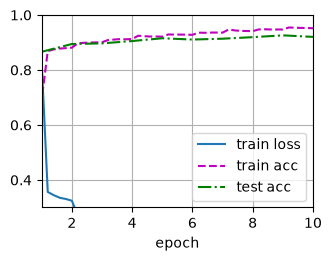

In [4]:
lr = 0.1
num_epochs = 10
batch_size = 50
train_iter, test_iter = util.data.load_data_fashion_mnist(batch_size, resize=224)
util.train.train_ch6(net, train_iter, test_iter, num_epochs, lr, device=util.try_gpu(), ylim=(0.3, 1.0))

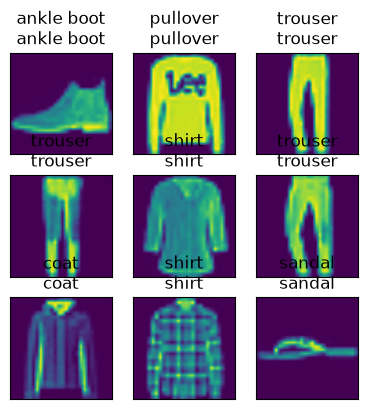

In [5]:
def predict(model, test_iter):
    """预测模型在测试集上的结果"""
    for X, y in test_iter:
        X = X.to(util.try_gpu())
        y = y.to(util.try_gpu())
        break
    trues = util.data.get_fashion_mnist_labels(y)
    preds = util.data.get_fashion_mnist_labels(model(X).argmax(dim=1))
    titles = [true + '\n' + pred for true, pred in zip(trues, preds)]
    util.show_images(X[0:9].reshape(9, 224, 224).cpu(), 3, 3, titles=titles[0:9])

predict(net, test_iter)

In [6]:
torch.save(net.state_dict(), './models/AlexNet.pth')
